# data

### 大语言模型的训练阶段

| 英文术语 | 中文术语 | 解释 |
| :--- | :--- | :--- |
| **Pre-training** | **预训练** | 在海量的、未标注的**原始文本数据**上进行训练。这些数据通常来自互联网（如网页、书籍、维基百科等）。这个阶段的目的是让模型学习语言的基本语法、语义、事实知识以及世界观。 |
| **Mid-training** | **中段训练** | 在**高质量数据**上进行额外的训练。这一阶段的目标是增强模型的特定能力，例如逻辑推理、数学能力或代码生成。这些高质量数据通常经过精心筛选和处理。 |
| **Post-training** | **后训练** | 在**指令遵循数据**上进行微调或使用强化学习（如RLHF, 人类反馈强化学习）。这个阶段的目的是让模型学会**理解和执行用户的指令**，使其能够更好地进行对话、问答或完成特定任务。 |

---

### 模型的术语

| 英文术语 | 中文术语 | 解释 |
| :--- | :--- | :--- |
| **Base model** | **基础模型** | 经过**预训练和中段训练**后的模型。它拥有强大的语言理解和生成能力，但可能不太擅长直接与人进行对话或遵循复杂指令。它更像一个“知识库”。 |
| **Instruct/chat model** | **指令/聊天模型** | 经过**后训练（指令微调）**后的模型。它在基础模型的基础上，学会了如何更好地与用户交互，**遵循指令**并进行自然流畅的对话。这就是我们日常使用的ChatGPT或文心一言这类模型。 |

---

### 核心思想总结



> 训练过程的核心是从**大量低质量数据**（用于基础知识学习）到**少量高质量数据**（用于能力增强和指令对齐）。

这个过程好比一个学生：
* **预训练**就像他阅读了海量书籍，掌握了基础知识。
* **中段训练**就像他针对性地做了很多高质量习题，提高了特定领域的解题能力。
* **后训练**就像他学会了如何和老师、同学交流，理解并完成他们的要求，最终成为一个能与人顺畅沟通的“AI助手”。

##  大规模语言模型的数据集概览

### 数据对象的类型
-   **实时服务 (Live service)**: 例如 Reddit，数据是实时流动的。
-   **原始快照 (Raw snapshot)**: 通过网络爬虫、API或数据转储（dumps）获取的原始数据。
-   **处理过的文本 (Processed text)**: 经过各种过滤和转换后的文本数据。
-   **聚合数据集 (Aggregated datasets)**: 例如 Dolma, The Pile，将多个数据源聚合在一起形成的大规模数据集。

### 数据来源
-   **人工标注者 (Annotators)**: 例如 Llama 2 的指令数据，由人工进行标注。
-   **真实用户 (Real users)**: 例如 ShareGPT，收集真实用户的对话数据。
-   **精选数据 (Curated)**: 例如从 Common Crawl 中精选出的数据。
-   **从更强模型中蒸馏 (Distilled from stronger model)**: 例如从 GPT-4 生成的合成数据。
-   **自蒸馏 (Self-distillation)**: 从正在训练的模型本身生成合成数据。

---

## BERT 的训练数据
-   **[Devlin+ 2018]**
-   BERT 的训练数据主要由 **BooksCorpus** 和 **Wikipedia** 组成。
-   **重要**: BERT 的训练序列是**文档**，而不是句子。这与 [Chelba+ 2013] 的十亿词基准数据集（来自机器翻译的句子）形成对比。

### BooksCorpus
-   **Smashwords**: 成立于2008年，允许任何人自助出版电子书。2024年有15万作者，50万本书。
-   **BooksCorpus [Zhu+ 2015]**: 从 Smashwords 爬取的零价自助出版书籍。
    -   包含 **7千本书**，约 **9.85亿个词**。
    -   因违反 Smashwords 的服务条款，该数据集已被下架。

### Wikipedia
-   **简介**: 免费的在线百科全书，创建于2001年。2024年拥有6200万篇文章，涵盖329种语言。
-   **范围**:
    -   不包含原创思想（无观点、促销、个人网页等）。
    -   文章内容基于**知名度**（来自可靠来源的重要报道）。
-   **内容贡献者**:
    -   任何互联网用户都可以编辑，破坏性编辑会被管理员回滚。
    -   少数维基人贡献了大部分内容（例如，Steven Pruit 进行了500万次编辑）。
-   **数据转储**: 每隔几周定期发布数据转储。
    -   
-   **数据投毒攻击 (Data poisoning attacks)**: **[Carlini+ 2023]**
    -   **漏洞**: 可以在定期数据转储发生前，恶意注入编辑，使其在编辑被回滚前被收录。
    -   **利用**: 注入示例，使模型对特定短语（如 iPhone）产生负面情感。**[Wallace+ 2020]**
    -   **启示**: 即使是高质量的来源，也可能包含不良内容。

---

## GPT-2 的训练数据
-   **WebText**: 用于训练 GPT-2 的数据集。**[Radford+ 2019]**
    -   包含来自 Reddit 帖子中** karma ≥ 3** 的外链页面，karma 值被视为数据质量的代理指标。
    -   共 **800万个页面**，**40GB 文本**。
-   **OpenWebTextCorpus**: WebText 的开源复现。**[Gokaslan+ 2019]**
    -   从 Reddit 提交数据集中提取所有 URL。
    -   使用 Facebook 的 fastText 过滤非英语内容。
    -   移除了近似重复的数据。

##  Common Crawl 数据集详解

### Common Crawl 概览
-   **Common Crawl** 是一个成立于2007年的非营利组织。
-   它大约**每月**进行一次网页爬取。
-   从2008年到2025年，已进行了约 **100次** 爬取。
-   2016年，一次爬取需要10-12天，动用100台机器。
-   最近一次爬取是2025年4月。
-   每次爬取的数据存在一些重叠，但会努力实现多样化。
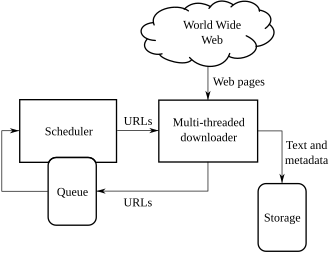
### 爬取过程
-   使用 **Apache Nutch** 工具进行爬取。
-   从数亿个**种子URL**开始。
-   将页面下载到队列中，并把页面中的超链接添加到队列中，形成一个递归的爬取过程。

### 爬取策略
-   **选择策略 (Selection policy)**: 决定哪些页面需要下载。
-   **礼貌策略 (Politeness policy)**: 遵守 `robots.txt` 协议，避免服务器过载。
-   **重访策略 (Re-visit policy)**: 确定检查页面内容是否更新的频率。
-   **挑战**: URL具有动态性，并且许多URL指向基本相同的内容，这给爬取带来了挑战。

### 数据格式
-   **WARC (Web Archive)**: 存储**原始的HTTP响应**，例如HTML内容。
-   **WET (Web Extracted Text)**: 将原始数据转换为**纯文本格式**，这是一个有损（lossy）过程。

### HTML 到文本的转换
-   将HTML转换为纯文本的工具有：**trafilatura** 和 **resiliparse**。
-   **DCLM 论文 [Li+ 2024]** 表明，这种转换过程对下游任务的准确性有重要影响。




# 过滤common crawl的办法
##  CCNet 数据集和工具详解

### CCNet 概览
-   **CCNet** 是一个用于自动构建大规模、高质量预训练数据集的工具和方法。
-   **[Wenzek+ 2019]**
-   其主要目标是为预训练模型提供高质量的数据，尤其关注**低资源语言**（例如乌尔都语）。

### CCNet 核心组件
-   **去重 (Deduplication)**: 基于轻量级的规范化方式，移除重复的段落。
-   **语言识别 (Language identification)**: 运行 `fastText` 语言识别分类器，只保留目标语言（例如英语）的文档。
-   **质量过滤 (Quality filtering)**: 使用一个 **KenLM 5-gram 模型**来筛选文档，只保留那些与维基百科内容相似的高质量文档。

### 结果
-   使用 CCNet 训练的 BERT 模型，其性能**优于**在维基百科上训练的模型。
-   **CCNet** 一词既指代开源工具，也指代该论文发布的**数据集**。

## 使用模型来筛选数据和使用规则来筛选数据的优劣

-----

| 特性 | 基于规则筛选数据 (Rule-based Filtering) | 基于模型筛选数据 (Model-based Filtering) |
| :--- | :--- | :--- |
| **工作原理** | 依赖于人工预先设定的硬性规则，如关键词匹配、正则表达式、长度限制等。 | 依赖于从大量数据中学习到的复杂模式，通过训练好的分类器进行判断。 |
| **优点** | **透明和可解释：** 逻辑清晰，易于理解和调试。 \<br\> **计算高效：** 成本低，处理速度快，适合大规模数据粗筛。 \<br\> **可控性强：** 结果可预测，能精确排除特定内容。 | **泛化能力强：** 能识别出新颖或不常见的低质量内容，鲁棒性高。 \<br\> **适应性好：** 可通过微调适应新的数据分布和质量标准。 \<br\> **处理复杂任务：** 能评估更高层面的质量，如文本连贯性、信息价值等。 |
| **缺点** | **缺乏泛化能力：** 难以处理多样化的数据，无法识别规则之外的异常情况。 \<br\> **维护成本高：** 规则集需要不断更新以应对新的数据类型。 \<br\> **不全面：** 很难制定出覆盖所有低质量内容的规则。 | **计算成本高：** 训练和推理需要大量的计算资源（GPU/TPU）。 \<br\> **可解释性差：** 决策过程通常是“黑箱”，难以解释。 \<br\> **可能引入偏见：** 训练数据中的偏见会被模型学习，影响筛选结果。 \<br\> **依赖于标注数据：** 需要大量高质量的标注数据来训练模型。 |
| **典型应用** | 过滤HTML标签、代码、广告、重复行等。 \<br\> T5 C4数据集中的**人工启发式规则**。 | 判断文档质量、内容相关性、风格匹配等。 \<br\> GPT-3数据处理中的**质量分类器**。 |
| **推荐用法** | **作为第一步**，快速去除显而易见的垃圾数据，进行**粗筛**。 | **作为第二步**，在规则筛选后进行**精筛**，进一步提升数据质量。 |
### C4 数据集 (T5)
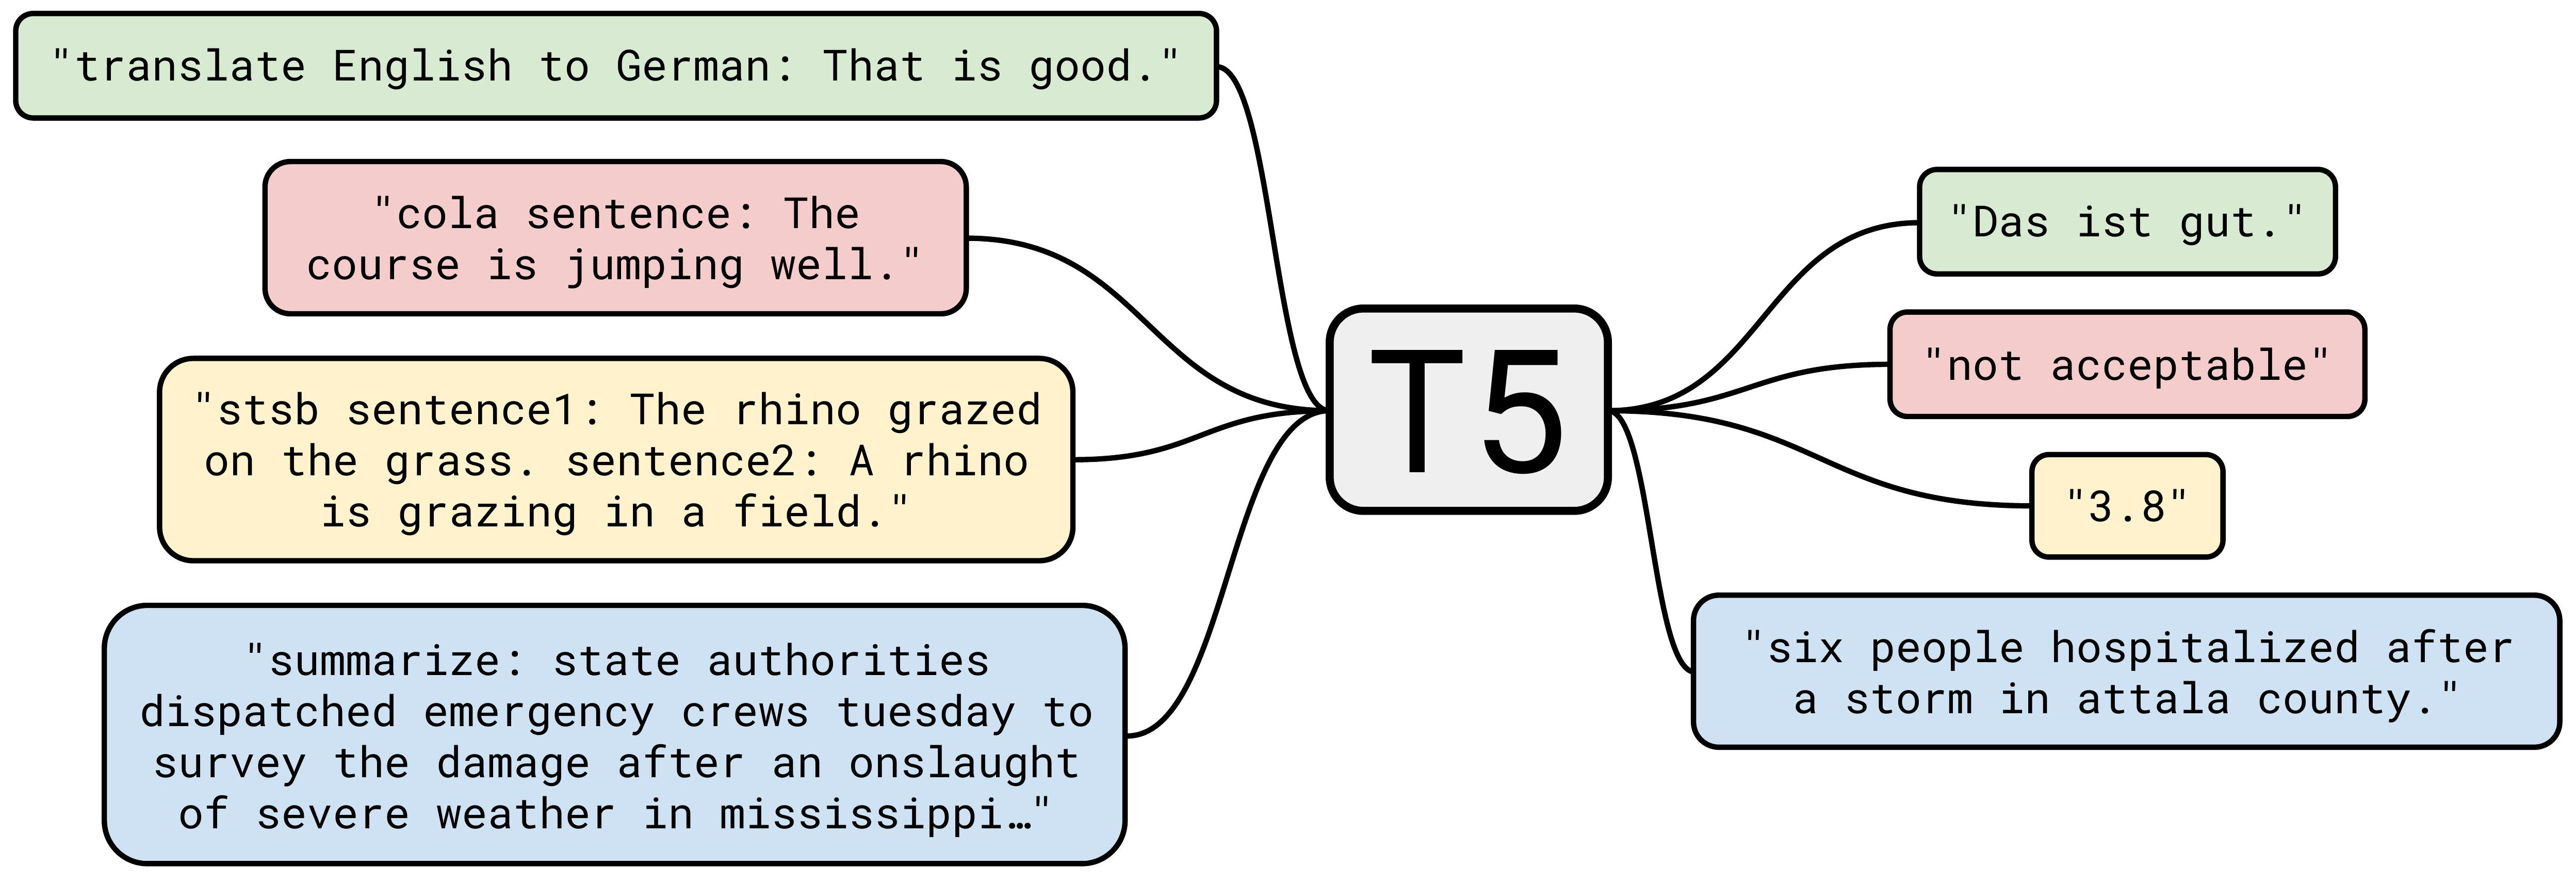
-   **全称**: **Colossal Clean Crawled corpus (C4)**
-   **出处**: **[Raffel+ 2019]**
-   **背景**: 论文主要以**T5 (Text-to-text Transfer Transformer)** 闻名，T5 将所有NLP任务统一到一种格式。
-   **主要贡献**: C4 数据集是该论文的一项重大贡献。
-   **核心观察**: 认为 **Common Crawl** 的大部分内容都不是有用的自然语言。
-   **数据来源**: 从 Common Crawl 的一个快照（2019年4月）开始，原始数据量为 **1.4万亿个 token**。
-   **人工启发式规则**:
    -   保留以标点符号结尾且词数大于等于5的行。
    -   移除句子少于3个的页面。
    -   移除包含“不良词汇”的页面。
    -   移除包含 `{`（用于过滤代码）、`lorem ipsum`、`terms of use` 等的页面。
    -   使用 `langdetect` 过滤非英语文本，要求英语概率达到0.99。
-   **最终结果**: **806 GB** 文本，约 **1560亿个 token**。
-   **C4 分析 [Dodge+ 2021]**: 该工作直接提供了可用的数据集，而不仅仅是脚本。
-   **额外**: 
    -   还提供了类似 **WebText** 的数据集，通过过滤来自 **OpenWebText** 链接的页面（Reddit 帖子中 karma ≥ 3 的链接）。
    -   使用12个数据转储得到了 **17 GB** 文本（WebText 为40 GB，这表明 CommonCrawl 的数据存在不完整性）。
    -   该数据集在各种NLP基准测试（如GLUE、SQuAD）上都取得了性能提升。
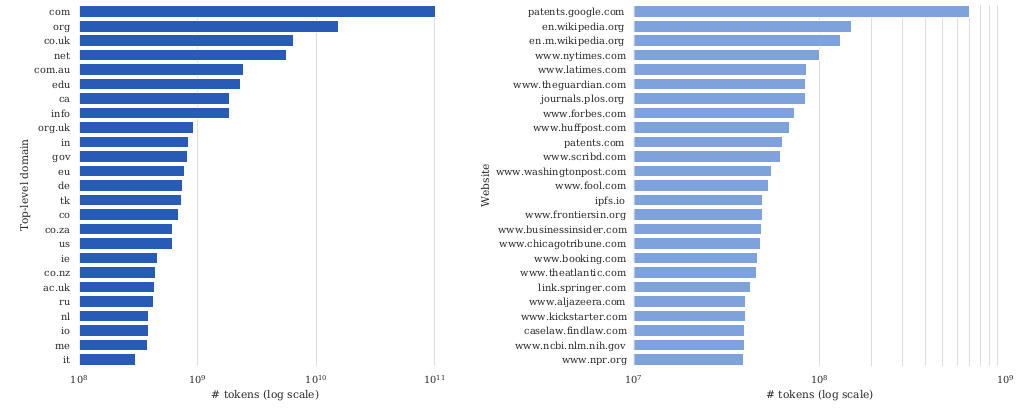
---

### GPT-3 数据集
-   **出处**: **[Brown+ 2020]**
-   **数据组成**:
    -   **Common Crawl** (经过处理)
    -   **WebText2** (扩展了更多链接的 WebText)
    -   神秘的 **基于互联网的书籍语料库** (Books1, Books2)
    -   **Wikipedia**
-   **最终结果**: **570 GB** 的文本，约 **4000亿个 token**。
-   **Common Crawl 处理过程**:
    -   训练了一个质量分类器，用于区分来自 `{WebText, Wikipedia, Books1, Books2}` 的高质量内容和其余内容。
    -   对文档进行模糊去重，包括 WebText 和基准测试集。

## The Pile 数据集详解

### The Pile 概览
-   **The Pile** **[Gao+ 2020]** 是一个大规模、多样化的语言建模数据集。
-   它的创建是为了响应 GPT-3，是开源社区努力构建开源语言模型的一部分。
-   这是一个由大量志愿者在Discord上协作完成的“草根”项目。
-   该数据集精心筛选了 **22个高质量的数据域**。
-   总数据量达到 **825 GB 的文本**（约 **2750亿个 token**）。
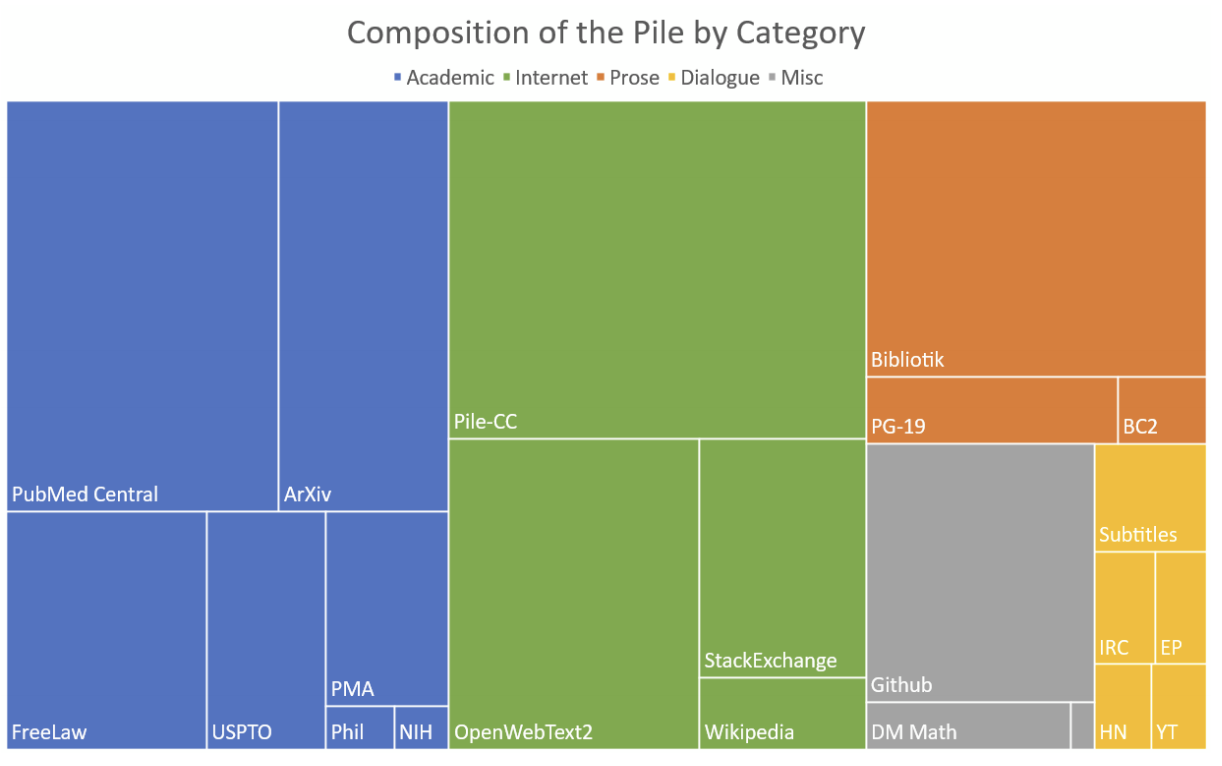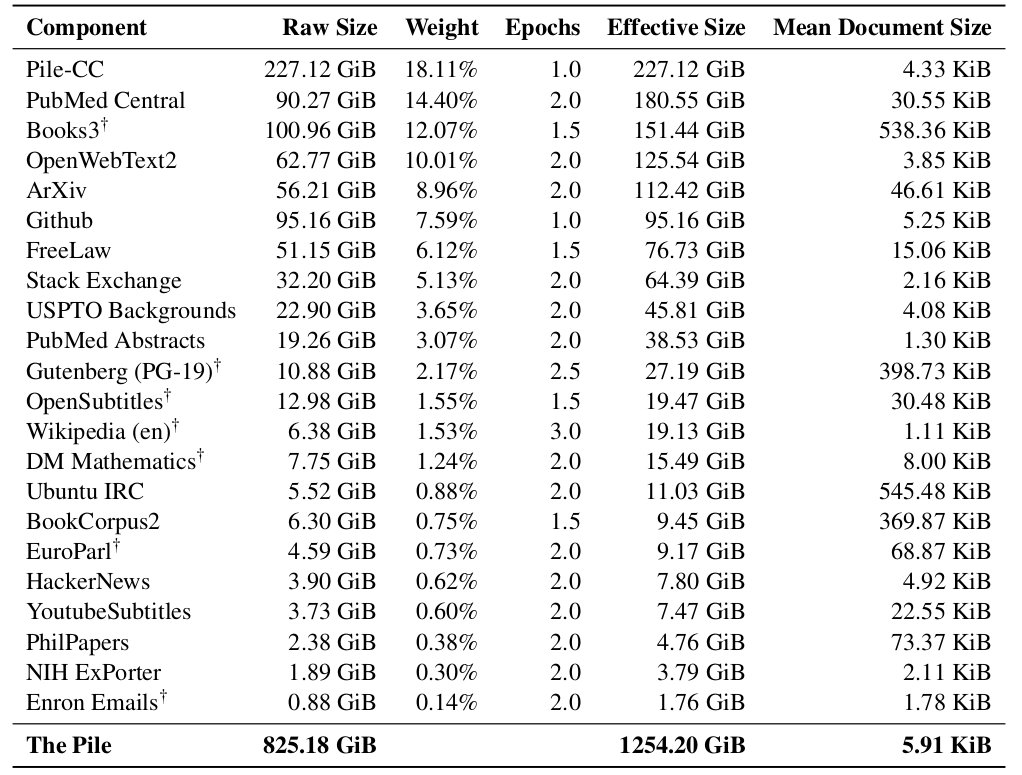
### 核心数据源
-   **Pile-CC**: 来自 **Common Crawl**，使用 **WARC** 格式，并通过 **jusText** 工具将其转换为文本（效果优于 WET 格式）。
-   **PubMed Central**: 包含500万篇论文，这些论文是NIH（美国国立卫生研究院）资助项目的公共成果。
-   **arXiv**: 自1991年以来用于发布研究论文预印本的平台（原始文件是 LaTeX 格式）。
-   **Enron 电子邮件**: 在2002年安然公司调查期间发布的，包含50万封来自150名安然高级管理人员的电子邮件。




## 大型语言模型数据集详解

### 图书数据集
-   **古登堡计划 (Project Gutenberg)**
    -   由 Michael Hart 于1971年发起，旨在增加文学作品的可及性。
    -   2025年，拥有约 **7.5万本** 书籍，主要为英语作品。
    -   只收录获得版权许可（大多属于公共领域）的书籍。
-   **Books3 [Presser, 2020]**
    -   包含来自“影子图书馆” **Bibliotik** 的 **19.6万本** 书籍。
    -   因侵犯版权和面临诉讼已被下架，其中包含斯蒂芬·金等知名作家的作品。
-   **影子图书馆 (Shadow libraries)**
    -   包括 **Library Genesis (LibGen), Z-Library, Anna's Archive, Sci-Hub** 等。
    -   绕过版权和付费墙，提供免费文献。
    -   常面临下架、诉讼和封锁，但通常能规避这些限制。
    -   有人认为这使本应免费的内容得以免费。
    -   Meta 公司曾使用 LibGen 的数据训练模型。

---

### 问答与代码数据集
-   **Stack Exchange**
    -   用户贡献的问答网站集合，始于2008年的 Stack Overflow。
    -   使用声望积分和徽章来激励参与。
    -   **问答格式**与**指令微调**或实际应用非常相似。
    -   数据转储为 XML 格式，包含元数据（用户、投票、评论、徽章等）。
-   **GitHub**
    -   代码对于编程任务非常有帮助，也被认为对**推理能力**有益。
    -   2018年被微软收购。
    -   2018年拥有至少 **2800万个** 公共代码仓库。
    -   一个代码仓库不全都是代码，还包含元数据（issue、提交历史等）。
    -   存在大量重复内容（如复制的代码、分支）。
-   **The Stack [Kocetkov+ 2022]**
    -   从 GH Archive 获取仓库名称（2015-2022）。
    -   克隆了 **1.37亿个** 仓库，510亿个文件（其中50亿个是独特的）。
    -   使用 `go-license-detector` 只保留许可宽松的（如 MIT, Apache）。
    -   使用 **MinHash 和 Jaccard 相似度**移除近似重复。
    -   最终结果：**3.1 TB** 的代码。

---

### 其他大规模数据集
-   **MassiveText (Gopher) [Rae+ 2021]**
    -   用于训练 Gopher 模型的数据集。
    -   **核心组成**: MassiveWeb、C4、图书、新闻、GitHub、维基百科。
    -   **MassiveWeb 过滤步骤**:
        -   保留英语、去重、避免训练-测试集重叠。
        -   使用**人工规则**进行质量过滤（例如：80%的词至少包含一个字母）。
        -   使用 Google SafeSearch 进行毒性过滤（而非词汇列表）。
    -   最终结果：**10.5 TB** 文本。

-   **LLaMA 数据集 [Touvron+ 2023]**
    -   总计 **1.2万亿个 token**。
    -   **数据源**:
        -   Common Crawl (经 CCNet 处理)。
        -   C4 (基于规则过滤)。
        -   GitHub (保留宽松许可，基于人工规则过滤)。
        -   维基百科 (2022年6-8月，20种语言，人工过滤)。
        -   古登堡计划和 Books3 (来自 The Pile)。
        -   arXiv (移除评论、扩展宏、参考文献)。
        -   Stack Exchange (28个最大网站，按得分排序答案)。
    -   **复现**: Together 公司的 **RedPajama v1** 和 Cerebras 公司的 **SlimPajama** (去重后的子集)。

-   **RefinedWeb [Penedo+ 2023]**
    -   核心观点：“**网络数据就足够了**”。
    -   **处理方法**:
        -   使用 **trafilatura** 将 HTML 转文本（从 **WARC** 文件）。
        -   **过滤**: 采用 **Gopher 规则**，避免基于机器学习的过滤以规避偏差。
        -   使用 **MinHash** 对5-gram进行模糊去重。
    -   发布了 **6000亿个** token (总共5万亿)。

-   **FineWeb**
    -   **动机**: 作为 RefinedWeb 的复现，并进行了改进。
    -   **数据来源**: 95个 Common Crawl 数据转储。
    -   **过滤**: URL过滤，语言ID（英语概率>0.65），并使用 **Gopher, C4** 等更多人工规则。
    -   使用 **MinHash** 进行模糊去重。
    -   **隐私**: 匿名化电子邮件和公开 IP 地址等 PII。
    -   最终结果：**15万亿个 token**。

## Dolma 数据集详解

### Dolma 概览
-   **Dolma** **[Soldaini+ 2024]** 是一个包含多样化高质量数据源的大规模数据集。
-   总数据量达到 **3万亿个 token**。
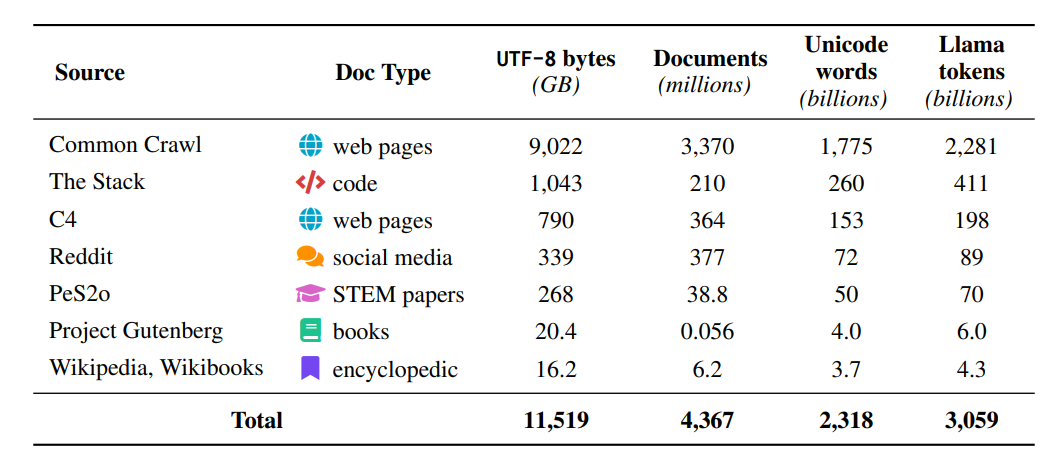
### 主要数据源
-   **Reddit**: 来自 Pushshift 项目（2005-2023年），包括独立的帖子（submissions）和评论（comments）。
-   **PeS2o**: 包含来自 Semantic Scholar 的 **4000万篇** 学术论文。
-   **C4**: Colossal Clean Crawled Corpus，一个大规模、经过清理的网络文本数据集。
-   **Project Gutenberg**: 古登堡计划，包含大量公共领域的电子书。
-   **Wikipedia/Wikibooks**: 维基百科和维基教科书的数据。

### Common Crawl 处理流程
-   **语言识别**: 使用 **fastText 分类器**进行语言识别，只保留英语内容。
-   **质量过滤**: 采用 **Gopher 和 C4 的规则**进行过滤，避免使用基于模型的过滤，以减少潜在的偏差。
-   **毒性过滤**: 使用**规则**和 **Jigsaw 分类器**进行毒性内容过滤。
-   **去重**: 使用**布隆过滤器 (Bloom filters)** 进行数据去重。


##  DataComp-LM (DCLM) 数据集详解

### DataComp-LM 概览
-   **DataComp-LM** **[Li+ 2024]** 是一个旨在为各种**数据处理算法**定义一个**标准数据集**的项目。
-   它通过处理 **Common Crawl** 数据来生成 **DCLM-pool**，该数据池包含 **240万亿个 token**。
-   **DCLM-baseline** 是从 DCLM-pool 中，通过使用**质量分类器**筛选后得到的子集。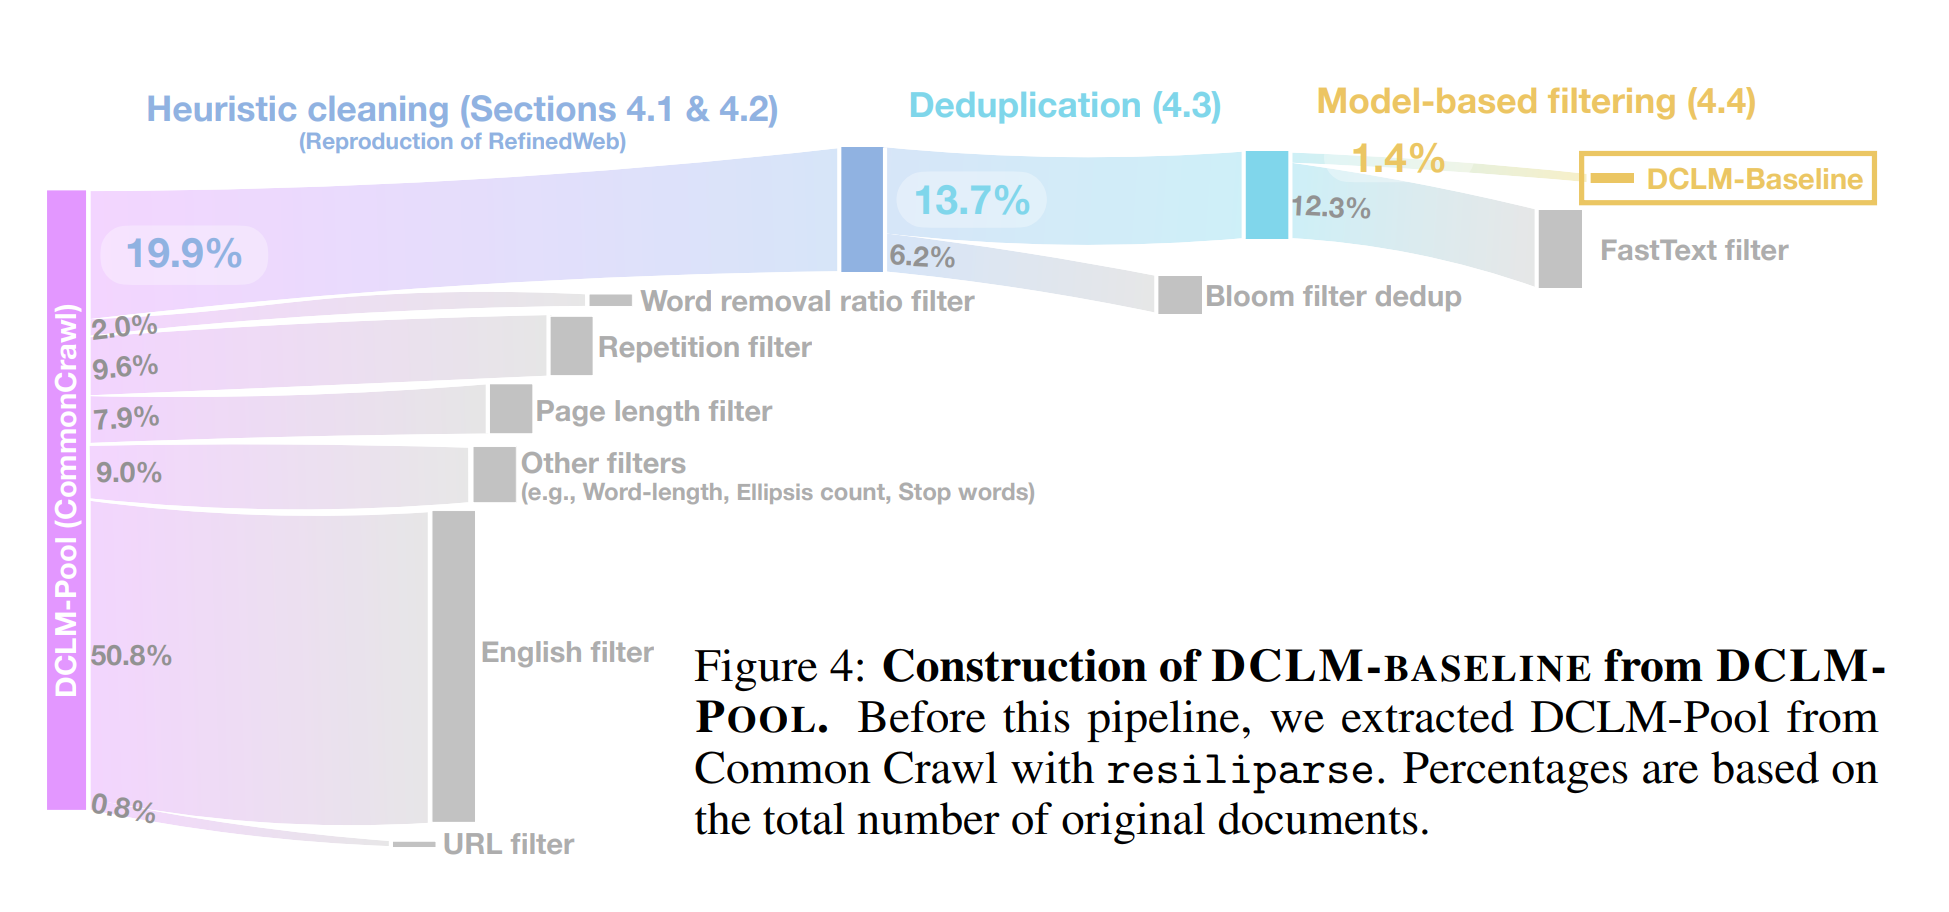


### 基于模型的过滤方法
-   **正面示例 (Positive examples)**:
    -   **OpenHermes-2.5**: 主要由 GPT-4 生成的指令数据。
    -   **ELI5**: 来自Reddit的“为我解释得像5岁小孩”版块，包含好奇心问答。
    -   共 **20万个** 正面示例。
-   **负面示例 (Negative examples)**:
    -   **RefinedWeb**。
    -   共 **20万个** 负面示例。
-   **结果**:
    -   训练了一个 **fastText 分类器**，并在整个 DCLM-pool 上运行。
    -   这个质量分类器在筛选性能上**优于**其他过滤方法。
    -   最终数据量达到 **3.8万亿** 个 token。
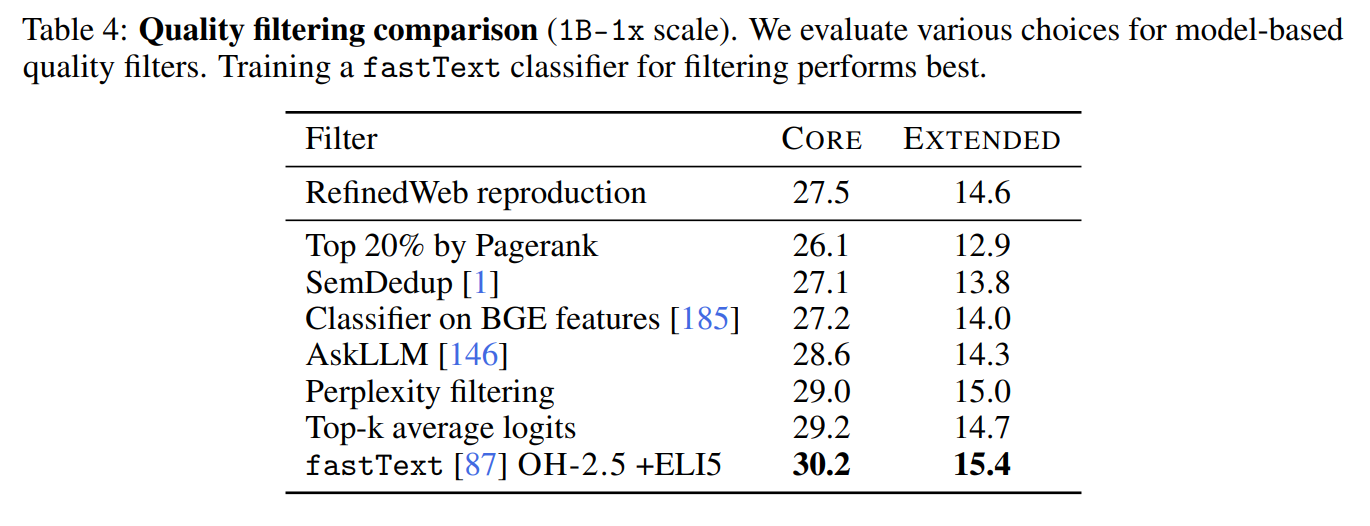
---

### Nemotron-CC 数据集
-   **Nemotron-CC** **[Su+ 2024]**
-   **动机**: 发现 FineWebEdu 和 DCLM 的过滤过于激进（移除了90%的数据），旨在获取更多 token，同时保持质量。
-   **HTML到文本转换**: 使用 **jusText**（而非 trafilatura），因为它返回的 token 更多。
-   **分类器集成 (Classifier ensembling)**:
    -   使用 Nemotron-340B-instruct 模型提示来评估 FineWeb 文档的教育价值，并将其知识蒸馏到一个更快的模型中。
    -   结合了 DCLM 分类器。
-   **合成数据改写 (Synthetic data rephrasing)**:
    -   对于高质量数据，使用大型语言模型（LLM）来改写低质量数据，以提升质量。
    -   对于低质量数据，使用 LLM 来生成任务，如问答对、提取关键信息等。
-   **结果**: **6.3万亿** 个 token（其中高质量子集为 **1.1万亿**）。
-   **对比**: LLaMA 3 训练于15万亿个 token，Qwen 3 训练于36万亿个 token。
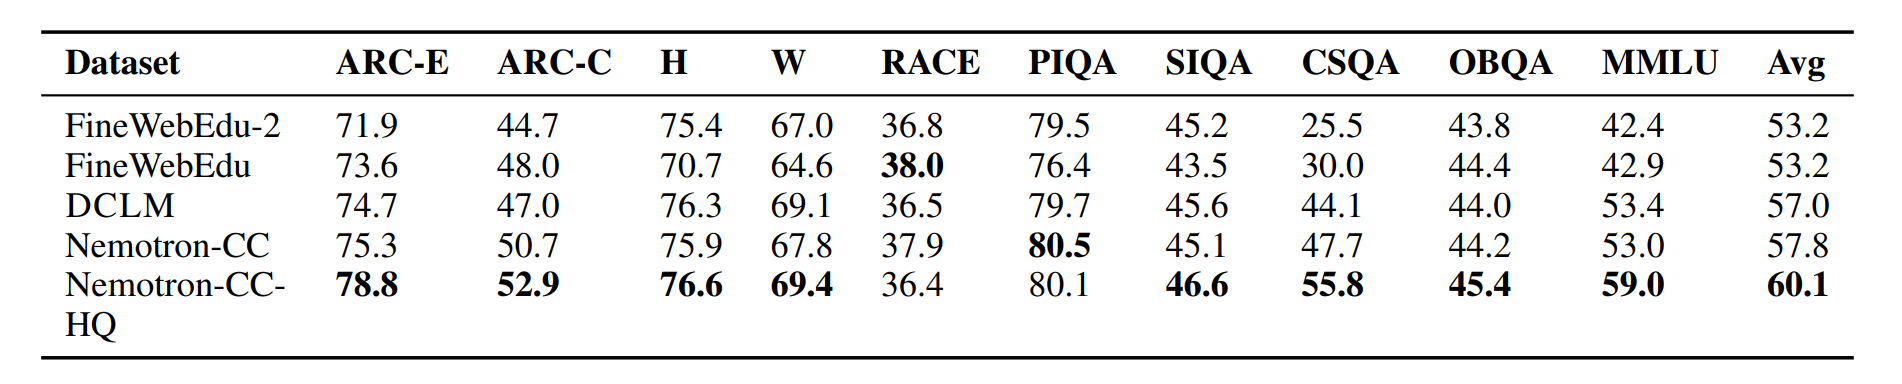
---

### 版权法与生成式AI
-   **背景**: 大量围绕生成式AI的诉讼，主要集中在**版权**问题。
-   **知识产权法 (Intellectual property law)**:
    -   **目标**: 激励智力产品的创作。
    -   **类型**: 版权、专利、商标、商业秘密。

#### 版权法 (Copyright law)
-   **起源**: 可追溯到1709年英国的《安妮法案》（Statute of Anne），首次由政府和法院进行规范。
-   **美国法律**: 最近的是《1976年版权法案》。
    -   **保护对象**: “固定在任何有形表达媒介上的**原创性作品**，现在已知或未来开发的，可以直接或借助机器或设备感知、复制或以其他方式交流的。”
    -   **原创性**: 仅限于**表达**，而非思想（如快速排序）。因此，除非在选择或编排上具有创造性，否则简单的集合（如电话簿）不受版权保护。
    -   **范围扩展**: 从“已出版”扩展到“已固定”。
    -   **注册**: 无需注册即可获得版权保护，但起诉侵权前需要注册。
    -   **有效期**: 通常为75年，之后进入**公共领域**（如莎士比亚、贝多芬的作品）。
    -   **结论**: 互联网上的绝大多数内容都受版权保护。

#### 如何使用受版权保护的作品
-   **获取许可 (Get a license)**:
    -   许可是一种合同法上的概念，本质上是“不被起诉的承诺”。
    -   **知识共享许可 (Creative Commons license)** 允许免费分发受版权保护的作品，被维基百科、Flickr 等广泛使用。
    -   许多模型开发者会**购买数据许可**来训练基础模型，例如：Google 和 Reddit、OpenAI 和 Shutterstock、OpenAI 和 StackExchange。
-   **援引合理使用条款 (Appeal to the fair use clause)**:
    -   **《1976年版权法案》第107条**，用于判断是否属于合理使用，需考虑四个因素：
        1.  **使用目的和性质**: 教学优于商业，**转换性**（transformative）使用优于复制性使用。
        2.  **受版权作品的性质**: 事实性优于虚构性，非创造性优于创造性。
        3.  **使用部分的大小和重要性**: 使用片段优于使用整个作品。
        4.  **对原作品市场的影响**: 是否会损害原作品的市场或潜在市场。
    -   **合理使用示例**:
        -   观看电影并撰写影评。
        -   重新实现一个算法（思想）而非复制其代码（表达）。
        -   Google Books 索引并显示摘要（《作家协会诉Google案》）。
    -   **核心**: 版权不是关于逐字记忆，而是关于**语义和经济**。戏仿可能属于合理使用。

#### 对基础模型的考量
-   **复制数据**（训练的第一步）本身就可能构成侵权。
-   训练机器学习模型是一种**转换性**使用，因为它将数据转化为模型的参数。
-   ML系统关注**思想**（如“停车标志”），而非具体的表达（如特定停车标志图像的艺术选择）。
-   **主要问题**: 语言模型可能会对创作者（如作家、艺术家）的市场产生影响，无论是否涉及版权。
-   **服务条款 (Terms of service)**: 即使有许可或合理使用权，服务条款也可能施加额外限制，例如 YouTube 禁止下载视频。



## 长上下文、任务与指令微调

### 长上下文模型
-   **需求**: 在文档、书籍上进行问答等任务，对长上下文处理能力有巨大需求。
-   **代表模型**:
    -   **DeepSeek v3**: 128K tokens。
    -   **Claude 3.5 Sonnet**: 200K tokens。
    -   **Gemini 1.5 Pro**: 1.5M tokens。
-   **训练挑战**: Transformer 模型对序列长度的依赖是二次方的，因此在预训练阶段直接处理长上下文效率低下，通常选择后续再增加长上下文能力。
-   **长上下文微调方法**:
    -   **LongLoRA [Chen+ 2023]**:
        -   将 Llama 2 7B 模型的上下文长度从 4K 扩展到 100K tokens。
        -   使用了**偏移稀疏注意力 (shifted sparse attention)** 和**位置插值 (positional interpolation)** 技术。
        -   在长文档数据集（如 PG-19 和 Proof-Pile）上进行训练。

---

### 任务导向型数据集
-   **核心思想**: 将大量现有 NLP 数据集转换成**提示（prompts）** 格式。
-   **Super-Natural Instructions [Wang+ 2022]**:
    -   包含超过 **1600个** 任务。
    -   通过社区（GitHub）贡献任务。
    -   每个任务的示例都来自现有数据集，并被转换成**模板化提示**。
    -   在 T5 上进行 k-shot 学习微调（Tk-instruct）。
    -   尽管模型小得多，但其性能优于 InstructGPT。
-   **Flan 2022 [Longpre+ 2023]**:
    -   包含超过 **1800个** 任务。
    -   在 T5 上进行微调，数据集包括**零样本 (zero-shot)**、**少样本 (few-shot)** 和**思维链 (chain-of-thought)** 版本。

---

### 指令与聊天微调
-   **核心思想**: 更加开放式的指令，大量使用**合成数据**。
-   **Alpaca [Taori+ 2023]**:
    -   使用 `text-davinci-003` 通过 **self-instruct** 方法生成了 **5.2万个** 示例。
    -   用该数据集微调了 LLaMA 7B 模型。
-   **Vicuna**:
    -   在来自 **ShareGPT** 的 **7万个** 对话数据上微调了 LLaMA 模型。
-   **Baize [Xu+ 2023]**:
    -   通过 **self-chat** 方法从 GPT-3.5 生成了 **11.15万个** 示例（使用 Quora 和 Stack Overflow 问题作为种子）。
    -   用该数据集微调了 LLaMA 模型。
-   **WizardLM [Xu+ 2023]**:
    -   使用 **Evol-Instruct** 数据集，通过“进化”问题来增加问题的广度和难度。
    -   用该数据集微调了 LLaMA 模型。
-   **MAmmoTH2 [Yue+ 2024]**:
    -   从 Common Crawl 中精心筛选了 **1000万条** 指令（WebInstruct）。
    -   **过滤**: 训练一个 fastText 分类器来识别类似问答网站的页面。
    -   **提取**: 使用 GPT-4 和 Mixtral 来提取问答对。
    -   用该数据微调了 Mistral 7B 模型，显著提升了数学性能。
-   **OpenHermes 2.5**:
    -   整合了许多数据集。
    -   用来自 GPT-4 的 **100万个** 示例微调了 Mistral 7B 模型。
-   **Llama 2 Chat [Touvron+ 2023]**:
    -   使用了 **27540个** 高质量、由供应商标注的指令数据。
    -   作者认为这种高质量数据优于开源数据集中数百万个示例。
    -   可以花费更少精力在标注上，将更多精力用于**强化学习人类反馈（RLHF）** 数据。
-   **Llama-Nemotron 训练后数据 [NVIDIA, 2024]**:
    -   **提示**: 来自公共数据集（如 WildChat）或合成生成后过滤。
    -   **响应**: 使用 Llama、Mixtral、DeepSeek r1、Qwen 等模型生成合成响应，这些模型具备商业可用性。
    -   **特点**: 包含推理过程（reasoning traces）。